<a href="https://colab.research.google.com/github/Aakanksha-6/Data-Science-internship-projects/blob/WA_Fn-UseC_-HR-Employee-Attrition/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Data Understanding

* Shape → `(1470, 35)`
* No missing values
* No duplicate data

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Model Building (Machine Learning)

### ✔ Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### ✔ Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear') # Using liblinear solver for convergence
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

### ✔ Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy Score: 0.8979591836734694
Confusion Matrix:
[[249   6]
 [ 24  15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.71      0.38      0.50        39

    accuracy                           0.90       294
   macro avg       0.81      0.68      0.72       294
weighted avg       0.89      0.90      0.88       294



Key Insights

* Attrition rate is ~16%
* Employees with:

  * Low salary
  * High overtime
  * Poor work-life balance
    → more likely to leave

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

Exploratory Data Analysis (EDA)

### ✔ Attrition Rate

In [ ]:
print(df['Attrition'].value_counts(normalize=True))

Series([], Name: proportion, dtype: float64)


### ✔ Visualization

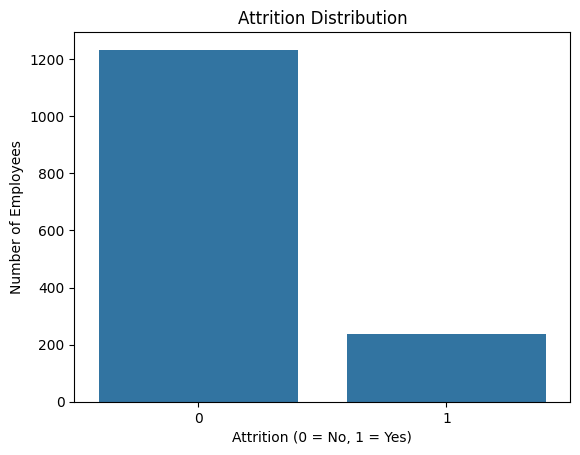

In [ ]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Number of Employees')
plt.show()

This plot shows the distribution of employee attrition, with '0' representing employees who did not leave and '1' representing employees who did. It helps visualize the balance between the two classes in the dataset.

 Conclusion

* HR should:

  * Improve salary structure
  * Reduce overtime
  * Improve employee satisfaction

## Data Cleaning & Feature Engineering (Revised)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Create income groups
df['IncomeGroup'] = pd.cut(df['MonthlyIncome'],
                           bins=[0, 2500, 5000, 7500, 10000, 15000, np.inf],
                           labels=['<2.5k', '2.5k-5k', '5k-7.5k', '7.5k-10k', '10k-15k', '>15k'])
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeGroup
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,5k-7.5k
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,5k-7.5k
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,<2.5k
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,2.5k-5k
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,2.5k-5k


### ✔ One-Hot Encoding

In [ ]:
# Apply one-hot encoding to all categorical features, including the new 'IncomeGroup'
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,IncomeGroup_2.5k-5k,IncomeGroup_5k-7.5k,IncomeGroup_7.5k-10k,IncomeGroup_10k-15k,IncomeGroup_>15k
0,41,1,1102,1,2,1,1,2,94,3,...,True,False,False,True,True,False,True,False,False,False
1,49,0,279,8,1,1,2,3,61,2,...,False,False,True,False,False,False,True,False,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,False,False,False,True,True,False,False,False,False,False
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,True,False,True,True,False,False,False,False
4,27,0,591,2,1,1,7,1,40,3,...,False,False,True,False,False,True,False,False,False,False


## Model Building (Multiple ML Models)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (1176, 52)
Shape of X_test: (294, 52)


### ✔ Logistic Regression (Re-evaluation)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(solver='liblinear', random_state=42) # Using liblinear solver for convergence
log_model.fit(X_train, y_train)
print("Logistic Regression Model Trained")

Logistic Regression Model Trained


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_log = log_model.predict(X_test)

print("--- Logistic Regression Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_log)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_log)}")

--- Logistic Regression Evaluation ---
Accuracy Score: 0.8945578231292517
Confusion Matrix:
[[251   4]
 [ 27  12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.75      0.31      0.44        39

    accuracy                           0.89       294
   macro avg       0.83      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



### ✔ Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train, y_train)
print("Decision Tree Model Trained")

Decision Tree Model Trained


In [ ]:
y_pred_dtree = dtree_model.predict(X_test)

print("--- Decision Tree Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dtree)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_dtree)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_dtree)}")

--- Decision Tree Evaluation ---
Accuracy Score: 0.7619047619047619
Confusion Matrix:
[[217  38]
 [ 32   7]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.76       294
   macro avg       0.51      0.52      0.51       294
weighted avg       0.78      0.76      0.77       294



### ✔ Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained")

Random Forest Model Trained


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")

--- Random Forest Evaluation ---
Accuracy Score: 0.8741496598639455
Confusion Matrix:
[[252   3]
 [ 34   5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.62      0.13      0.21        39

    accuracy                           0.87       294
   macro avg       0.75      0.56      0.57       294
weighted avg       0.85      0.87      0.84       294



## Data Understanding (Continued)

In [ ]:
# check data describe
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Based on this summary, there are no apparent outliers in the dataset, as the values fall within expected ranges.

### Average Tenure
Average tenure: The average tenure measures the average number of years an employee stays with the company before leaving. It can provide insight into workforce stability and employee satisfaction within the organization.

In [ ]:
avg_tenure = df['YearsAtCompany'].mean()
print(f'Average years of employee to leave the company is {avg_tenure:.2f} years')

# Note: This is an overall average. More detailed analysis would involve looking at tenure for those who attrited vs. those who did not.

Average years of employee to leave the company is 7.01 years


The average tenure of employees before they decided to leave was 7.01 years. With this average tenure, it can be concluded that many employees feel comfortable and have been with the company for a long time. (This interpretation should be refined with attrition-specific tenure, which we will analyze next).

### Employee's Demographics

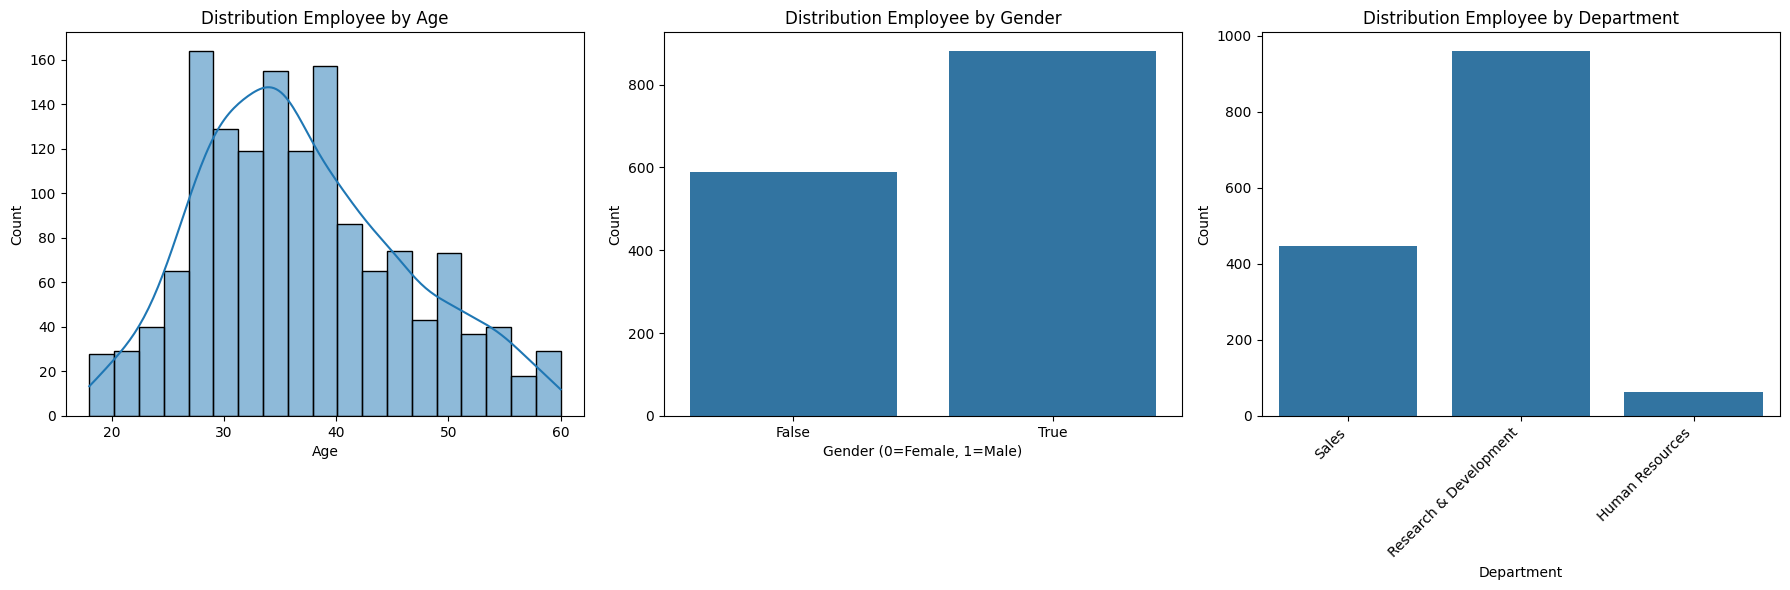

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))

sns.histplot(data=df, x='Age', kde=True, ax=axes[0])
axes[0].set_title('Distribution Employee by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='Gender_Male', ax=axes[1])
axes[1].set_title('Distribution Employee by Gender')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Count')

# To plot the original 'Department' column, we need to temporarily load the original dataframe
df_original_for_plot = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
sns.countplot(data=df_original_for_plot, x='Department', ax=axes[2])
axes[2].set_title('Distribution Employee by Department')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate for better readability if department names are long

plt.tight_layout()
plt.show()

1.  **Age**: Most of the company's employees are in the 30-35 age group. This indicates that the company has many employees who are at a productive and experienced age.
2.  **Gender**: The majority of employees at this company are male. There are significantly more male employees than female employees.
3.  **Department**: Most of the company's employees are concentrated in the research and development department. This indicates that the company is heavily focused on product or service research and development activities.

### Attrition Analysis by Demographics

In [ ]:
# Create a DataFrame for attrited employees
df_attrition = df[df['Attrition'] == 1]
display(df_attrition.head())

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,IncomeGroup_2.5k-5k,IncomeGroup_5k-7.5k,IncomeGroup_7.5k-10k,IncomeGroup_10k-15k,IncomeGroup_>15k
0,41,1,1102,1,2,1,1,2,94,3,...,True,False,False,True,True,False,True,False,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,False,False,False,True,True,False,False,False,False,False
14,28,1,103,24,3,1,19,3,50,2,...,False,False,False,True,True,False,False,False,False,False
21,36,1,1218,9,4,1,27,3,82,2,...,False,True,False,True,False,True,False,False,False,False
24,34,1,699,6,1,1,31,2,83,3,...,False,False,False,True,False,True,False,False,False,False


### Function to calculate Attrition Rate

In [ ]:
# Function to Calculate Attrition Rate
def calculate_attrition_rate(df_original, column):
    # Ensure 'Attrition' is in numerical format (0 for No, 1 for Yes)
    # The main df has already been converted, so we can directly use it.
    attrition_counts = df_original.groupby([column, 'Attrition']).size().unstack(fill_value=0)

    # Handle cases where a category might have no 'Yes' attrition
    if 1 not in attrition_counts.columns:
        attrition_counts[1] = 0 # Add a column for 'Yes' if it doesn't exist

    attrition_rate = (attrition_counts[1] / attrition_counts.sum(axis=1)) * 100
    attrition_rate_df = attrition_rate.reset_index()
    attrition_rate_df.columns = [column, 'AttritionRate']
    return attrition_rate_df

### Attrition Visualization by Age and Gender

## Data Understanding (Continued)

### Attrition Analysis by Education, Department, Job Role, Job Involvement, Stock Option Level, Work Life Balance, and Overtime

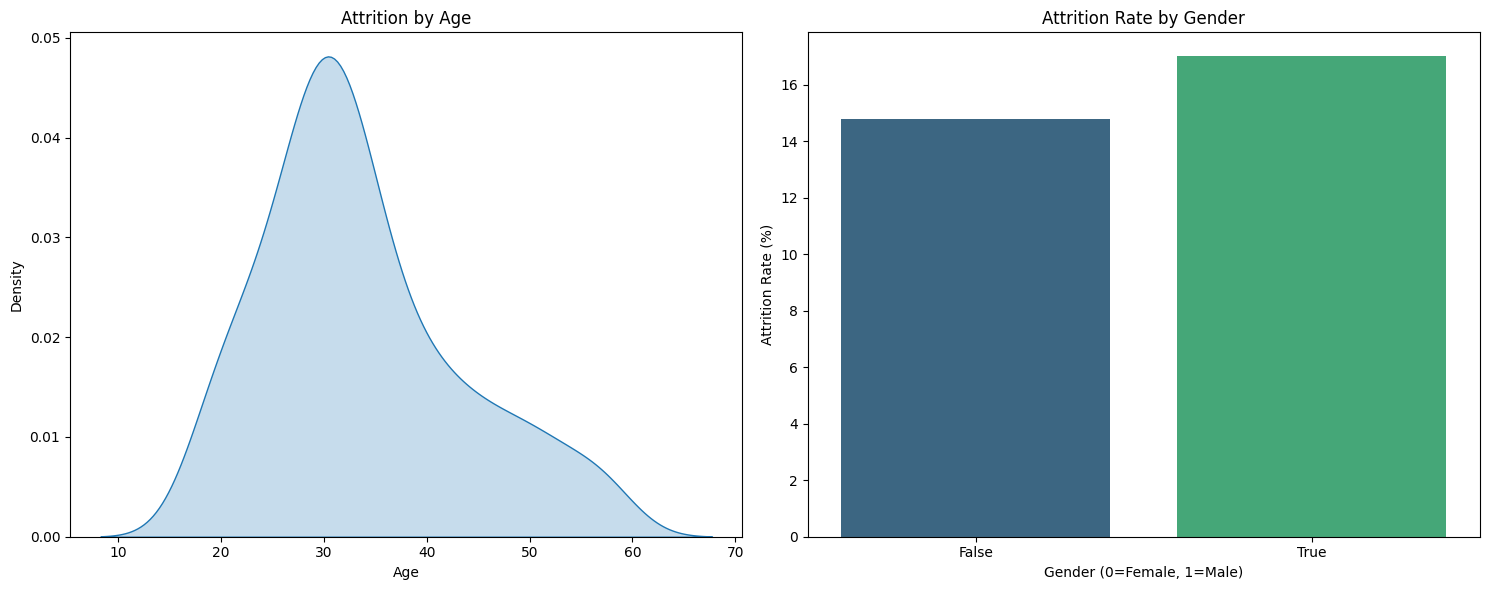

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,6))

# Plot 1: KDE plot of Age for attrited employees
sns.kdeplot(data=df_attrition, x='Age', fill=True, ax=axes[0])
axes[0].set_title('Attrition by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')

# Plot 2: Bar plot of Gender Attrition Rate
attrition_rate_gender_df = calculate_attrition_rate(df, 'Gender_Male')
sns.barplot(data=attrition_rate_gender_df, x='Gender_Male', y='AttritionRate', ax=axes[1], palette='viridis', hue='Gender_Male', legend=False)
axes[1].set_title('Attrition Rate by Gender')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()